In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

df = pd.read_csv("FourRegionData.csv")
df.head(10)


,Region,Year,Month,SoilTemperature-10,SoilTemperature-30,SoilTemperature-50,Rainfall,Temperature,Min Temperature,Max Temperature,Humidity,Sunshine,Wind Speed,Surface Pressure,Solar Radiation
0,2,2001,1,17.40,18.81,19.43,0,18.38,13.04,25.44,62.68,7.94,2.17,101268.29,199.25
1,2,2001,2,19.88,19.98,20.36,1,22.61,16.90,28.56,61.71,7.19,1.98,101039.08,210.73
2,2,2001,3,24.08,23.32,23.17,33,26.62,20.73,31.84,55.48,8.75,2.10,100882.56,251.75
3,2,2001,4,27.62,27.02,26.77,46,29.06,24.71,32.06,65.63,8.55,2.70,100655.40,257.46
4,2,2001,5,28.54,28.29,28.21,402,27.69,24.18,32.09,77.39,6.10,2.37,100234.63,172.32
5,2,2001,6,30.11,29.82,29.64,386,28.03,25.55,31.75,83.17,3.51,3.64,99934.18,140.45
6,2,2001,7,30.74,30.53,30.64,202,28.83,25.92,31.60,80.26,4.55,3.87,99991.05,169.40
7,2,2001,8,30.99,30.99,30.86,205,29.46,25.23,31.50,82.19,5.15,3.01,100129.68,181.66
8,2,2001,9,29.83,29.89,29.95,209,28.71,24.34,32.42,82.53,4.65,2.14,100499.17,170.22
9,2,2001,10,28.00,28.29,28.50,177,27.63,22.83,31.44,80.45,5.60,1.59,100864.38,167.89


In [6]:

# Feature and target selection
features = df[['Month', 'Temperature', 'Min Temperature',
               'Max Temperature', 'Surface Pressure']]
target = df['SoilTemperature-10']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

target_scaler = MinMaxScaler()
y_scaled = target_scaler.fit_transform(target.values.reshape(-1, 1))

# Sliding window function
def create_sliding_window(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i+window_size])
        ys.append(y[i+window_size])
    return np.array(Xs), np.array(ys)

# Loop over window sizes
histories=[]
comparisons={}
window_sizes = [3, 6, 9, 12]
for WINDOW in window_sizes:
    print(f"\n======================")
    print(f"🔁 Training with WINDOW SIZE: {WINDOW}")
    print(f"======================")

    X_seq, y_seq = create_sliding_window(X_scaled, y_scaled, WINDOW)

    total_samples = len(X_seq)
    train_end = int(0.7 * total_samples)
    val_end = int(0.85 * total_samples)

    X_train, y_train = X_seq[:train_end], y_seq[:train_end]
    X_val, y_val = X_seq[train_end:val_end], y_seq[train_end:val_end]
    X_test, y_test = X_seq[val_end:], y_seq[val_end:]

    # Define GRU model
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        GRU(32, return_sequences=True),
        GRU(32, return_sequences=False),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    checkpoint = ModelCheckpoint(f'best_model_window_{WINDOW}.h5', monitor='val_loss', save_best_only=True, mode='min')
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

    # Train
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stop, checkpoint, lr_scheduler],
        verbose=0
    )
    histories.append(history.history)
    # Evaluate model
    loss, mae = model.evaluate(X_test, y_test)
    print(f'WINDOW SIZE={WINDOW}')
    print(f"✅ Test Loss (MSE): {loss:.4f}")
    print(f"✅ Test MAE:       {mae:.4f}")

    
    # Predictions
    predictions = model.predict(X_test)

    # Rescale predictions and actuals
    predictions_rescaled = target_scaler.inverse_transform(predictions)
    y_test_rescaled = target_scaler.inverse_transform(y_test.reshape(-1, 1))

    # === 📊 Extra Evaluation Metrics ===
    y_true = y_test_rescaled.flatten()
    y_pred = predictions_rescaled.flatten()
    y_mean = np.mean(y_true)

    # MAPE
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # R²
    r2 = r2_score(y_true, y_pred)

    # sMAPE
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

    # NSE
    nse = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_mean) ** 2)

    # Willmott's d-index
    d_index = 1 - (np.sum((y_true - y_pred) ** 2) /
                   np.sum((np.abs(y_pred - y_mean) + np.abs(y_true - y_mean)) ** 2))

    # ✅ Print all metrics
    print(f"✅RMSE:       {np.sqrt(loss):.3f}")
    print(f"✅ MAPE:     {mape:.2f}%")
    print(f"✅ R²:       {r2:.4f}")
    print(f"✅ sMAPE:    {smape:.2f}%")
    print(f"✅ NSE:      {nse:.4f}")
    print(f"✅ d-index:  {d_index:.4f}")
    # Show comparison
    comparison = pd.DataFrame({
        'Predicted': y_pred.flatten(),
        'Actual': y_true.flatten()
    })
    comparisons[WINDOW] = comparison
    print("\nSample Predictions:")
    print(comparison.head())



🔁 Training with WINDOW SIZE: 3


C:\Users\HP Laptop 15\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


5/5 [==============================] - 0s 4ms/step - loss: 0.0046 - mae: 0.0490
WINDOW SIZE=3
✅ Test Loss (MSE): 0.0046
✅ Test MAE:       0.0490
5/5 [==============================] - 1s 4ms/step
✅RMSE:       0.067
✅ MAPE:     3.42%
✅ R²:       0.9149
✅ sMAPE:    3.47%
✅ NSE:      0.9149
✅ d-index:  0.9789

Sample Predictions:
   Predicted  Actual
0  24.832127   24.99
1  20.718319   20.30
2  18.241590   19.42
3  21.685778   23.85
4  26.793400   29.19

🔁 Training with WINDOW SIZE: 6


C:\Users\HP Laptop 15\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


5/5 [==============================] - 0s 4ms/step - loss: 0.0042 - mae: 0.0483
WINDOW SIZE=6
✅ Test Loss (MSE): 0.0042
✅ Test MAE:       0.0483
5/5 [==============================] - 1s 3ms/step
✅RMSE:       0.064
✅ MAPE:     3.42%
✅ R²:       0.9224
✅ sMAPE:    3.44%
✅ NSE:      0.9224
✅ d-index:  0.9807

Sample Predictions:
   Predicted  Actual
0  25.093246   24.99
1  21.212803   20.30
2  18.382847   19.42
3  21.803482   23.85
4  26.764305   29.19

🔁 Training with WINDOW SIZE: 9


C:\Users\HP Laptop 15\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


5/5 [==============================] - 0s 5ms/step - loss: 0.0039 - mae: 0.0471
WINDOW SIZE=9
✅ Test Loss (MSE): 0.0039
✅ Test MAE:       0.0471
5/5 [==============================] - 1s 4ms/step
✅RMSE:       0.063
✅ MAPE:     3.32%
✅ R²:       0.9263
✅ sMAPE:    3.34%
✅ NSE:      0.9263
✅ d-index:  0.9817

Sample Predictions:
   Predicted  Actual
0  24.826347   24.99
1  20.671167   20.30
2  18.318085   19.42
3  21.748911   23.85
4  26.753931   29.19

🔁 Training with WINDOW SIZE: 12


C:\Users\HP Laptop 15\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


5/5 [==============================] - 0s 8ms/step - loss: 0.0042 - mae: 0.0466
WINDOW SIZE=12
✅ Test Loss (MSE): 0.0042
✅ Test MAE:       0.0466
5/5 [==============================] - 1s 4ms/step
✅RMSE:       0.064
✅ MAPE:     3.34%
✅ R²:       0.9227
✅ sMAPE:    3.33%
✅ NSE:      0.9227
✅ d-index:  0.9801

Sample Predictions:
   Predicted  Actual
0  21.132875   20.30
1  18.470070   19.42
2  21.895422   23.85
3  27.026432   29.19
4  29.954054   31.14


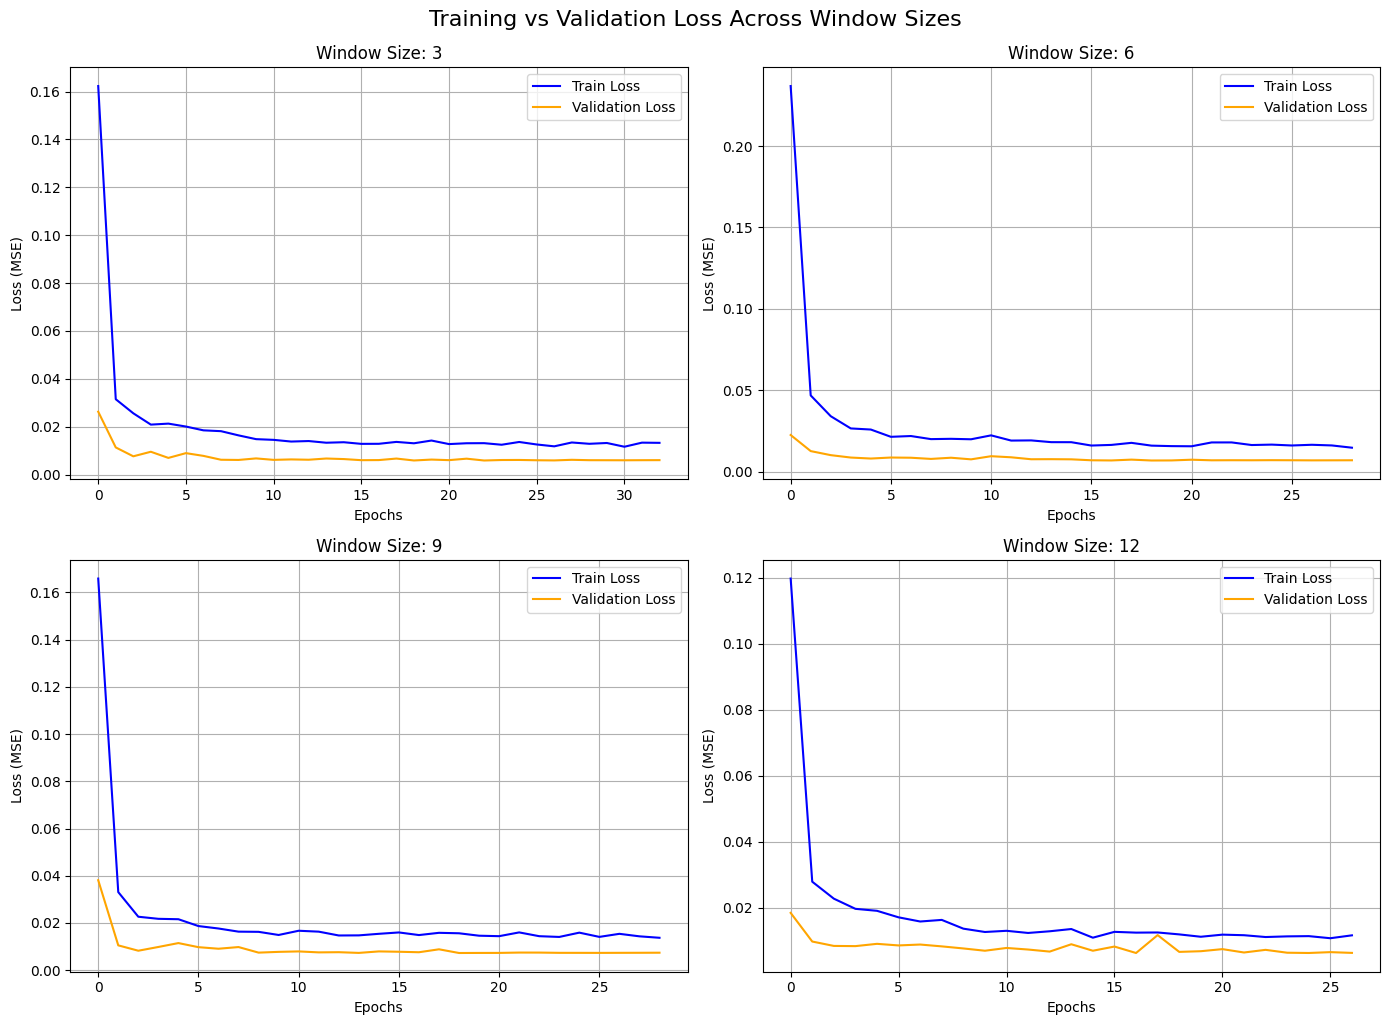

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, hist in enumerate(histories):
    window = window_sizes[i]
    ax = axes[i]
    ax.plot(hist['loss'], label='Train Loss', color='blue')
    ax.plot(hist['val_loss'], label='Validation Loss', color='orange')
    ax.set_title(f'Window Size: {window}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss (MSE)')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.suptitle('Training vs Validation Loss Across Window Sizes', fontsize=16, y=1.02)
plt.show()

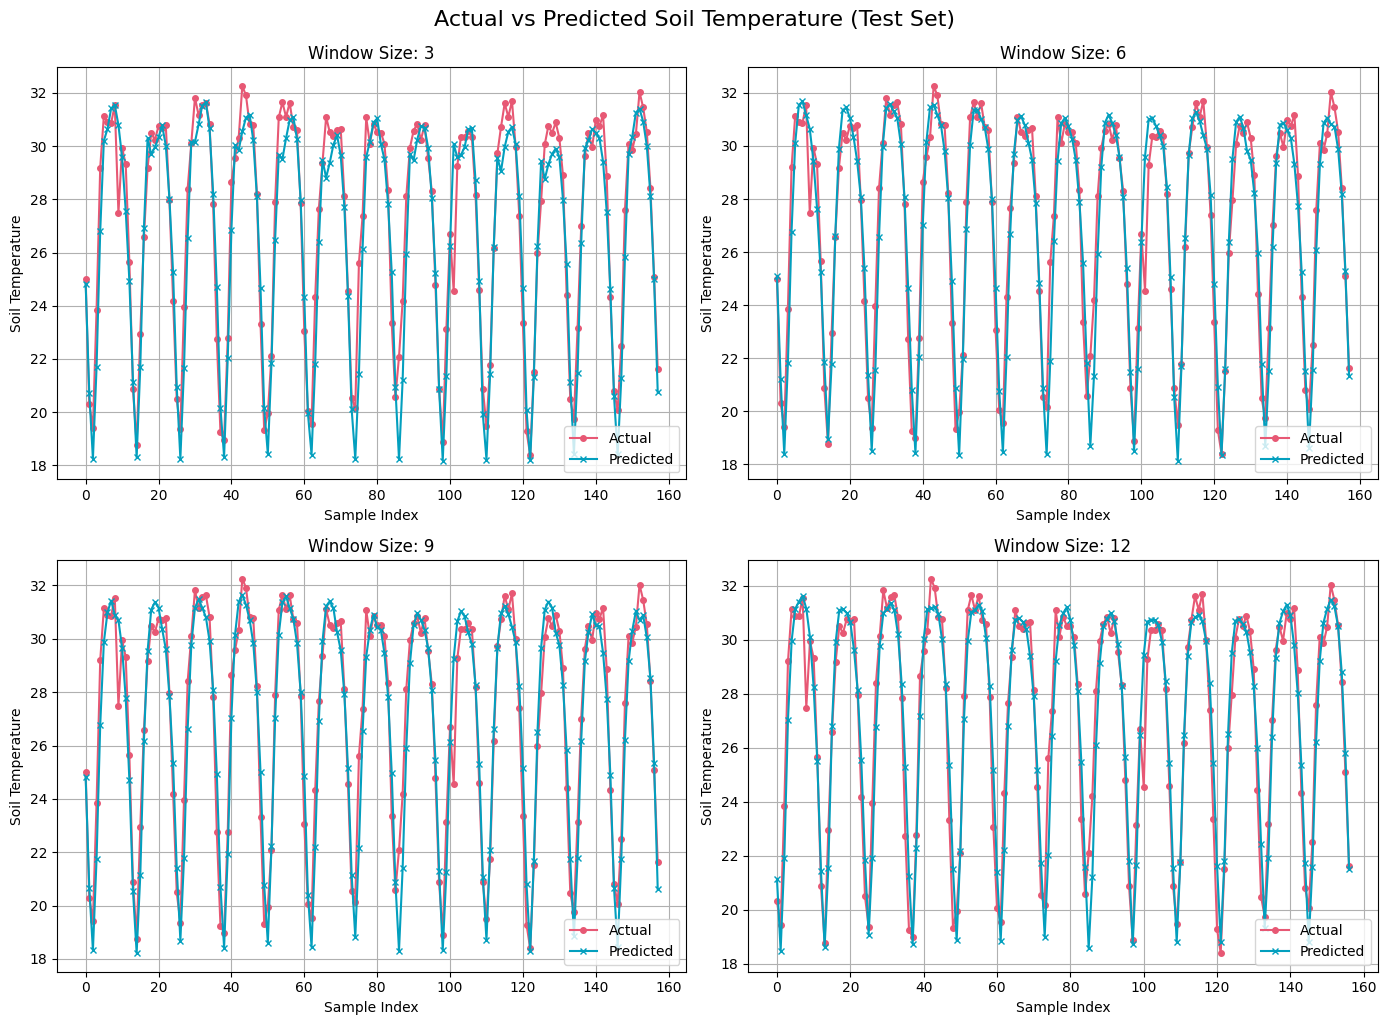

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, window in enumerate(window_sizes):
    ax = axes[i]
    comparison = comparisons[window]
    ax.plot(comparison['Actual'].values, label='Actual', marker='o', color='#e75874', markersize=4)
    ax.plot(comparison['Predicted'].values, label='Predicted', marker='x', color='#039fbe', markersize=4)
    ax.set_title(f'Window Size: {window}')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Soil Temperature')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.suptitle('Actual vs Predicted Soil Temperature (Test Set)', fontsize=16, y=1.02)
plt.show()